<a href="https://colab.research.google.com/github/DakshiAnanth06/Budget_Ease/blob/ML_models/notebooks/ML_models/BE_PIM_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import joblib


In [ ]:
df = pd.read_csv("BudgetEase_rawdata_with_income_type.csv")

df.columns = df.columns.str.strip()
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 12)


,Age,Main source of monthly income,Average Monthly Income (LKR),Main Monthly Expense Categories,Do you usually track your expenses?,Approximately how much do you spend per month as an undergraduate (in LKR)?,Enter your monthly spending for each category(LKR) [Essentials],Enter your monthly spending for each category(LKR) [Academic],Enter your monthly spending for each category(LKR) [Leisure],Enter your monthly spending for each category(LKR) [Other],Spender_Type,Income_Type
0,24-25,"Family support,Mahapola/ Bursary","Less than 10,000",Essentials,Never,"LKR 20,000 - 30,000",3500,2000,1500,2000,Balanced,Low income
1,18-20,Family support,"10,000 - 20,000",Academic,"Yes, regularly","LKR 20,000 - 30,000",4500,2500,2000,2500,Impulsive,Low income
2,21-23,Part-time job,"10,000 - 20,000",Essentials,Never,"Above LKR 30,000",4500,3500,1500,2000,Impulsive,Low income
3,Above 25,"Family support,Mahapola/ Bursary,Part-time job","Less than 10,000","Essentials,Leisure,Academic,Other",Sometimes,"LKR 10,000 - 20,000",3500,2000,1500,2000,Balanced,Low income
4,21-23,"Mahapola/ Bursary,Part-time job","20,000 - 30,000",Academic,Never,"LKR 10,000 - 20,000",5000,3000,1500,2000,Saver,Medium income


In [ ]:
df.rename(columns={
    "Main source of monthly income": "Main_Income_Source",
    "Average Monthly Income (LKR)": "Avg_Monthly_Income",
    "Main Monthly Expense Categories": "Main_Expense_Categories",
    "Approximately how much do you spend per month as an undergraduate (in LKR)?": "Approx_Monthly_Spending",
    "Enter your monthly spending for each category(LKR) [Essentials]": "Spending_Essentials",
    "Enter your monthly spending for each category(LKR) [Academic]": "Spending_Academic",
    "Enter your monthly spending for each category(LKR) [Leisure]": "Spending_Leisure",
    "Enter your monthly spending for each category(LKR) [Other]": "Spending_Other"
}, inplace=True)

print(df.columns.tolist())


['Age', 'Main_Income_Source', 'Avg_Monthly_Income', 'Main_Expense_Categories', 'Do you usually track your expenses?', 'Approx_Monthly_Spending', 'Spending_Essentials', 'Spending_Academic', 'Spending_Leisure', 'Spending_Other', 'Spender_Type', 'Income_Type']


In [ ]:
le_spender = LabelEncoder()
le_income = LabelEncoder()

df["Spender_Type_enc"] = le_spender.fit_transform(df["Spender_Type"])
df["Income_Type_enc"] = le_income.fit_transform(df["Income_Type"])


In [ ]:
age_mapping = {
    "18-20": 0,
    "21-23": 1,
    "24-25": 2,
    "Above 25": 3
}

df["Age"] = df["Age"].map(age_mapping)


In [ ]:
tracking_map = {
    "Yes regularly": 0,
    "Sometimes": 1,
    "Rarely": 2,
    "Never": 3
}

df["Do you usually track your expenses?"] = (
    df["Do you usually track your expenses?"].map(tracking_map)
)


In [ ]:
income_range_mapping = {
    "Less than LKR 10,000": 8000,
    "LKR 10,000 – 20,000": 15000,
    "LKR 20,000 – 30,000": 25000,
    "Above LKR 30,000": 35000
}

df["Avg_Monthly_Income"] = df["Avg_Monthly_Income"].map(income_range_mapping)
df["Approx_Monthly_Spending"] = df["Approx_Monthly_Spending"].map(income_range_mapping)


In [ ]:
df["Total_Spending"] = (
    df["Spending_Essentials"] +
    df["Spending_Academic"] +
    df["Spending_Leisure"] +
    df["Spending_Other"]
)

df = df[df["Total_Spending"] > 0]

df["Essentials_pct"] = df["Spending_Essentials"] / df["Total_Spending"] * 100
df["Academic_pct"]   = df["Spending_Academic"] / df["Total_Spending"] * 100
df["Leisure_pct"]    = df["Spending_Leisure"] / df["Total_Spending"] * 100
df["Other_pct"]      = df["Spending_Other"] / df["Total_Spending"] * 100


In [ ]:
df.drop(columns=[
    "Spending_Essentials",
    "Spending_Academic",
    "Spending_Leisure",
    "Spending_Other",
    "Total_Spending"
], inplace=True)


In [ ]:
income_source_map = {
    "Family support": 0,
    "Mahapola/ Bursary": 1,
    "Part-time job": 2,
    "Other": 3
}

def encode_multi_income(val):
    if not isinstance(val, str):
        return 0
    items = [v.strip() for v in val.split(",")]
    return np.mean([income_source_map.get(i, 0) for i in items])

df["Main_Income_Source"] = df["Main_Income_Source"].apply(encode_multi_income)


In [ ]:
expense_map = {
    "Essentials": 0,
    "Academic": 1,
    "Leisure": 2,
    "Other": 3
}

def encode_multi_expense(val):
    if not isinstance(val, str):
        return 0
    items = [v.strip() for v in val.split(",")]
    return np.mean([expense_map.get(i, 0) for i in items])

df["Main_Expense_Categories"] = df["Main_Expense_Categories"].apply(encode_multi_expense)


In [ ]:
X = df[
    [
        "Age",
        "Main_Expense_Categories",
        "Do you usually track your expenses?",
        "Approx_Monthly_Spending",
        "Avg_Monthly_Income",
        "Essentials_pct",
        "Academic_pct",
        "Leisure_pct",
        "Other_pct",
        "Main_Income_Source"
    ]
]

Y = df[["Spender_Type_enc", "Income_Type_enc"]]

print(X.dtypes)  # MUST be int/float only


Age                                      int64
Main_Expense_Categories                float64
Do you usually track your expenses?    float64
Approx_Monthly_Spending                float64
Avg_Monthly_Income                     float64
Essentials_pct                         float64
Academic_pct                           float64
Leisure_pct                            float64
Other_pct                              float64
Main_Income_Source                     float64
dtype: object


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y["Spender_Type_enc"]
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight="balanced",
        random_state=42
    )
)

model.fit(X_train_scaled, Y_train)


MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       max_depth=15,
                                                       n_estimators=300,
                                                       random_state=42))

In [ ]:
Y_pred = model.predict(X_test_scaled)

print("Spender Accuracy:",
      accuracy_score(Y_test.iloc[:,0], Y_pred[:,0]))

print("Income Accuracy:",
      accuracy_score(Y_test.iloc[:,1], Y_pred[:,1]))


Spender Accuracy: 0.7435
Income Accuracy: 0.8243


In [ ]:
print("Spender Type Report")
print(classification_report(
    Y_test.iloc[:,0],
    Y_pred[:,0],
    target_names=le_spender.classes_
))

print("Income Type Report")
print(classification_report(
    Y_test.iloc[:,1],
    Y_pred[:,1],
    target_names=le_income.classes_
))


Spender Type Report
              precision    recall  f1-score   support

    Balanced       0.82      0.78      0.80      4019
   Impulsive       0.62      0.83      0.71      2969
       Saver       0.83      0.61      0.70      3012

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.74     10000
weighted avg       0.76      0.74      0.74     10000

Income Type Report
               precision    recall  f1-score   support

  High income       0.73      0.88      0.80      2182
   Low income       0.93      0.82      0.87      5209
Medium income       0.74      0.79      0.76      2609

     accuracy                           0.82     10000
    macro avg       0.80      0.83      0.81     10000
 weighted avg       0.84      0.82      0.83     10000



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


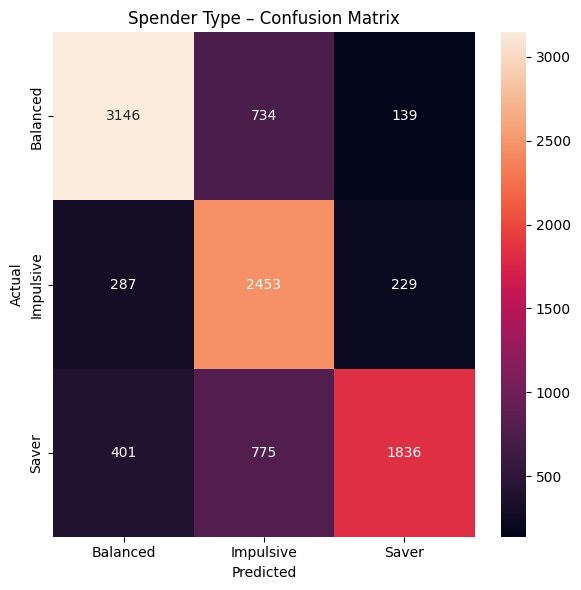

In [ ]:
cm_spender = confusion_matrix(
    Y_test.iloc[:, 0],
    Y_pred[:, 0]
)

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm_spender,
    annot=True,
    fmt="d",
    cmap="rocket",
    xticklabels=le_spender.classes_,
    yticklabels=le_spender.classes_
)

plt.title("Spender Type – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


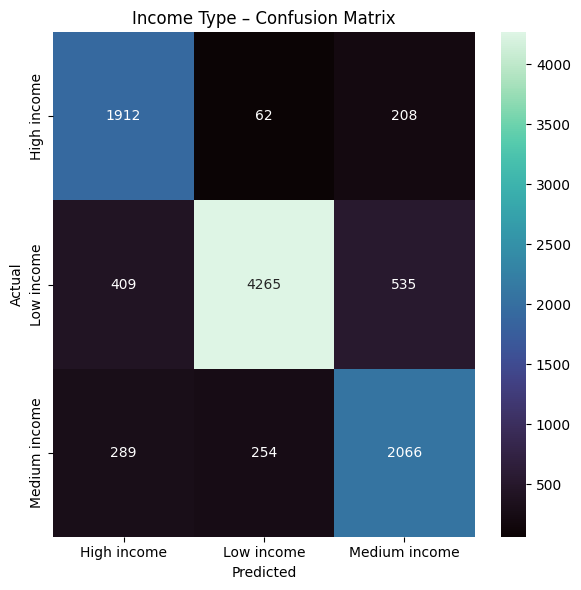

In [ ]:
cm_income = confusion_matrix(
    Y_test.iloc[:, 1],
    Y_pred[:, 1]
)

plt.figure(figsize=(6, 6))
sns.heatmap(
    cm_income,
    annot=True,
    fmt="d",
    cmap="mako",
    xticklabels=le_income.classes_,
    yticklabels=le_income.classes_
)

plt.title("Income Type – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
joblib.dump(model, "budgetease_multi_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_spender, "spender_encoder.pkl")
joblib.dump(le_income, "income_encoder.pkl")

print("✅ Model & preprocessors saved")


✅ Model & preprocessors saved
